# mGPLVM analysis on recurrent units

In [1]:
%load_ext autoreload
%autoreload 2
import os
import pickle
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch
from sklearn.linear_model import RidgeCV

import mgplvm as mgp
import utils as utils
from utils.path_settings import *


plt.rcParams['figure.titlesize'] = 12
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['xtick.labelsize'] = 8
plt.rcParams['ytick.labelsize'] = 8
plt.rcParams['legend.fontsize'] = 8
plt.rcParams['legend.handlelength'] = 1.5
plt.rcParams['legend.handleheight'] = 0.5
plt.rcParams['axes.spines.right'] = False
plt.rcParams[('axes.spines.top')] = False
device = mgp.utils.get_device()
torch.set_default_dtype(torch.float64)

loading
/home/timmy/nonnormal/dummy/mental-rotations


2025-05-20 13:56:48.903823: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-20 13:56:48.925286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-20 13:56:48.951698: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-20 13:56:48.951759: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-20 13:56:48.970380: I tensorflow/core/platform/cpu_feature_gua

In [2]:
model_name = "LAL_weight_decay"
neural_activations = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/network_activity_{model_name}.pt")
cx = torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/positions_{model_name}.pt")
positions = torch.tensor(cx[:, :2].reshape(-1, neural_activations.shape[-2], 2))
scaling = 1
positions[..., 1] = ((positions[..., 1] + np.pi) % (2 * np.pi) * scaling) + (1- scaling) * np.pi - np.pi
neural_activations = neural_activations.reshape(-1, neural_activations.shape[-1])
positions = positions.reshape(-1, positions.shape[-1])


In [3]:
!nvidia-smi

Tue May 20 13:14:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 ...    Off |   00000000:01:00.0  On |                  N/A |
| N/A   51C    P0             14W /  125W |     852MiB /   8188MiB |      2%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)

In [4]:
# Subsample the conditions
m = 8000
n = [64, 64, 32, 20]
load = False

if model_name is not None: 
    partitions = {
        "Internal Model": (0, 129),
        "Controller_hidden": (129, 129 + 128),
        "Controller_output": (257, 289), 
        "Continuous Attractor": (289, 545),
    }
else:
    partitions = {
        "Internal Model": (0, 128),
        "Predictive Model": (128, 258),
        "Controller": (258, 418),
        "Continuous Attractor": (418, 674),
    }
if load: 
    try: 
        indices = torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices.pt")
        subsampling_index_1 = indices["index 1"]
        subsampling_index_2 = indices["index 2"]
    except:
        print("No indices found; subsampling randomly")
        subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
else: 
    subsampling_index_1 = torch.randperm(neural_activations.shape[0])[:m]
    if model_name is None:
        subsampling_index_2 = torch.randperm(neural_activations.shape[-1])[:n]
    else:
        subsampling_index_2 = []
        for i, (partition_name, (start, end)) in enumerate(partitions.items()):
            partition_indices = torch.arange(start, end)
            sampled_indices = partition_indices[torch.randperm(len(partition_indices))[:n[i]]]
            subsampling_index_2.append(sampled_indices)
        subsampling_index_2 = torch.cat(subsampling_index_2)

neural_activations_subsampled = neural_activations.reshape(-1, neural_activations.shape[-1])[subsampling_index_1][:, subsampling_index_2]
positions_subsampled = positions.reshape(-1, positions.shape[-1])[subsampling_index_1]
print(f"Neural activations subsampled to shape {neural_activations_subsampled.shape}")
print(f"Positions subsampled to shape {positions_subsampled.shape}")
m, n = neural_activations_subsampled.shape
neural_activations_subsampled = neural_activations_subsampled.unsqueeze(0).permute(0, 2, 1).cpu().detach()


Neural activations subsampled to shape torch.Size([8000, 180])
Positions subsampled to shape torch.Size([8000, 2])


In [58]:
subsampling_index_2.shape

torch.Size([180])

(array([3665., 3660., 3556., 3167., 3347., 3413., 3502., 3608., 3718.,
        3808., 3628., 3165., 3065., 2982., 2843., 2980., 2938., 2936.,
        3024., 3054., 3084., 3063., 3013., 3199., 3078., 2613., 2333.,
        2295., 2309., 2351., 2596., 2571., 2847., 2859., 3186., 3173.,
        3377., 3476., 3622., 3487., 3662., 3747., 3892., 4077., 4492.,
        4246., 4083., 3851., 3620., 3579.]),
 array([3.42060484e-05, 1.25697196e-01, 2.51360208e-01, 3.77023190e-01,
        5.02686203e-01, 6.28349185e-01, 7.54012167e-01, 8.79675210e-01,
        1.00533819e+00, 1.13100123e+00, 1.25666416e+00, 1.38232720e+00,
        1.50799012e+00, 1.63365316e+00, 1.75931621e+00, 1.88497913e+00,
        2.01064205e+00, 2.13630509e+00, 2.26196814e+00, 2.38763118e+00,
        2.51329422e+00, 2.63895702e+00, 2.76462007e+00, 2.89028311e+00,
        3.01594615e+00, 3.14160919e+00, 3.26727223e+00, 3.39293504e+00,
        3.51859808e+00, 3.64426112e+00, 3.76992416e+00, 3.89558721e+00,
        4.02125025e+00, 

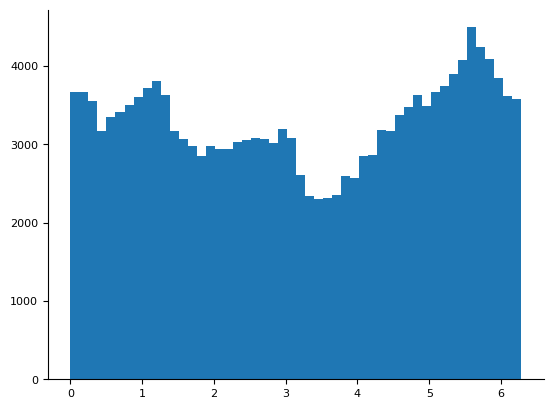

In [ ]:
plt.hist(positions[..., 0].cpu().reshape(-1, 1).numpy(), bins=50)

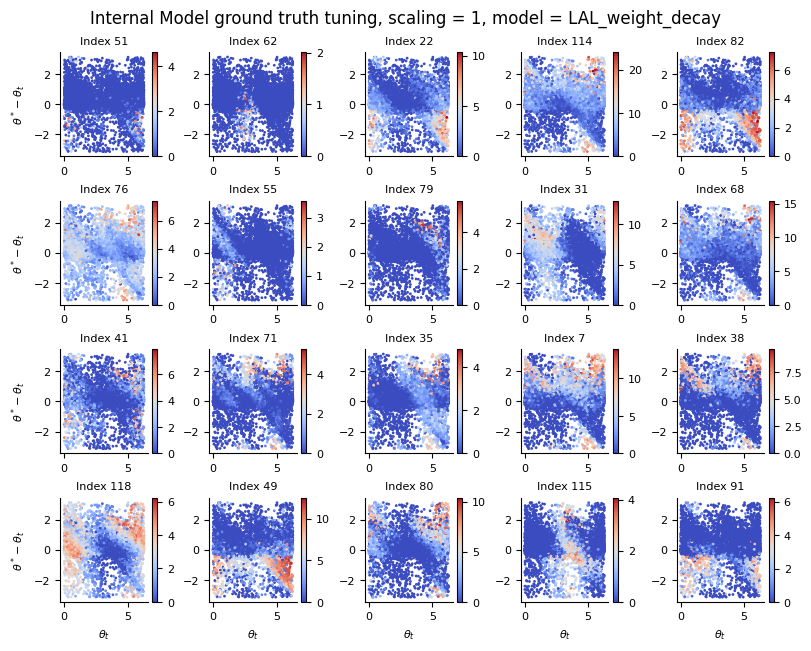

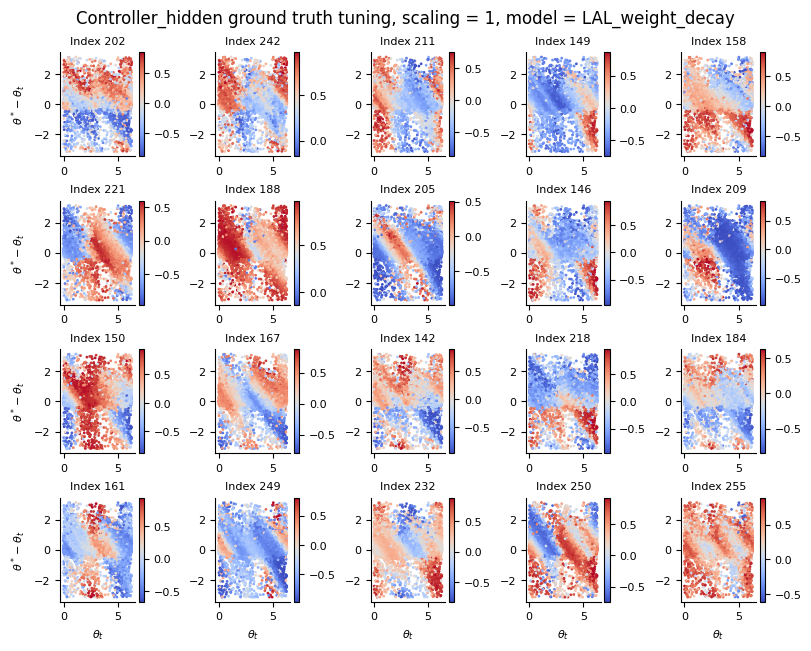

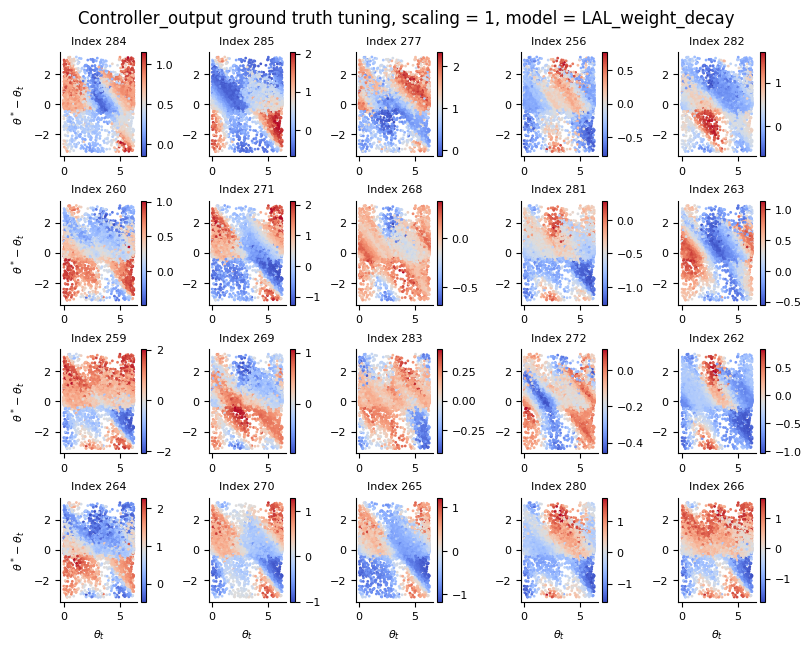

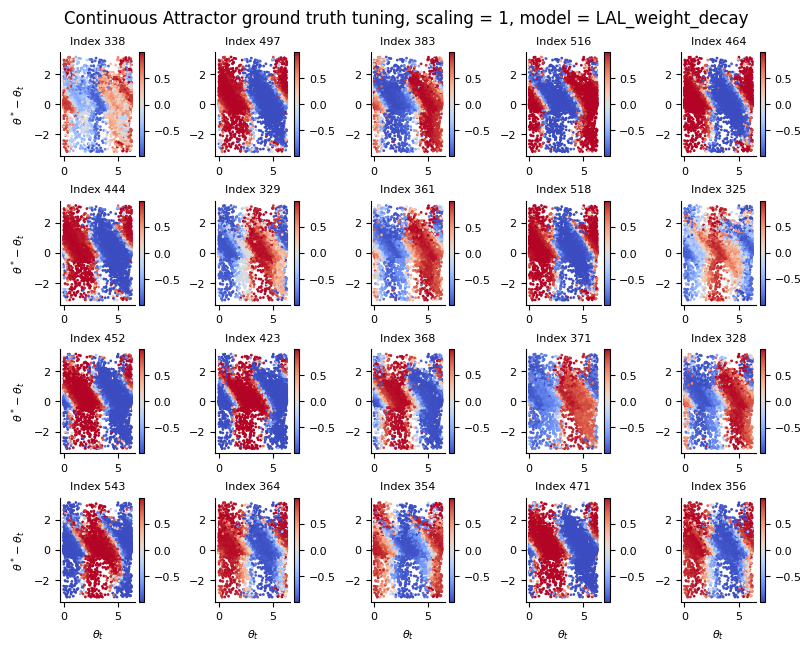

In [34]:
for partition_name, (start, end) in partitions.items():
    indices = [i for i in range(neural_activations_subsampled.shape[-2]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    # subset the neural activations for the current partition
    neural_activations_subset = neural_activations_subsampled[:, indices, :]
    num_neurons = neural_activations_subset.shape[-2]
    # determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # calculate rows dynamically based on number of neurons
    rows = 4
    # create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.scatter(
            positions_subsampled[:, 0],
            positions_subsampled[:, 1],
            c=neural_activations_subset[0, i, :],
            cmap="coolwarm",
            s = 1,
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")

    fig.suptitle(f"{partition_name} ground truth tuning, scaling = {scaling}{", model = " + model_name if model_name is not None else ""}", fontsize=12)
    plt.savefig(f"{FIG_PATH}/GT_modular_{partition_name}_scaling{scaling}{model_name if model_name is not None else ""}.png", dpi=300, bbox_inches='tight')


Now we have an idea of what stuff actually looks like, we try to fit the supervised mGPLVM to data. 

Note that this plot reveals bias in the sampling procedure. This is expected because we are sampling on control trajectories; expectedly as the controller is trained, the residual motion will be biased toward 0 (or 2pi). 

In [5]:
### set some parameters for fitting ###
max_steps = 1001 # number of training iterations
n_mc = 1 # number of monte carlo samples per iteration (since the latents are a delta function, we only need 1)
print_every = 10 # how often we print training progress
d = 2 # specify the dimensionality of the space
n_z = 50 #number of inducing points; performance increases with more inducing points

In [6]:
def build_model_supervised(): 
    manif = mgp.manifolds.Torus(m, d)
    mu = positions_subsampled.unsqueeze(0)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1, sigma = 1e-5, diagonal = True, mu = mu)
    kernel = mgp.kernels.QuadExp(n, manif.distance, Y = neural_activations_subsampled, ell = np.ones(n)*1, scale = 0.7*np.ones(n)) #squared exponential kernel
    # lik = mgp.likelihoods.Gaussian(n, Y = neural_activations_subsampled, d=d)
    lik = mgp.likelihoods.Gaussian(n, )
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, n_z)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior,
    ).to(device)
    return model

def build_model_unsupervised(): 
    manif = mgp.manifolds.Torus(m, d)
    lat_dist = mgp.rdist.ReLie(manif, m, n_samples=1)
    kernel = mgp.kernels.QuadExp(n, manif.distance)
    lik = mgp.likelihoods.Gaussian(n)
    lprior = mgp.lpriors.Uniform(manif)
    z = manif.inducing_points(n, 50)
    model = mgp.models.SvgpLvm(
        n, m, 1, z, kernel, lik, lat_dist, lprior, whiten = True
    )
    return model


model = build_model_supervised()
unsupervised_model = build_model_unsupervised()

/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/rdist/relie.py:120: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gmu = torch.tensor(mu)
/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/models/svgp.py:356: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1718580525958/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:1688.)
  l = torch.cholesky(kzz, upper=False)[None, ...]


In [16]:
scale = 1/10
manif = mgp.manifolds.Torus(m, d)
manif.distance(
    torch.tensor([[0.0, -np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
    torch.tensor([[0.0, np.pi * scale], ], dtype=torch.get_default_dtype()).unsqueeze(2),
)

tensor([[[0.3820]]])

In [8]:
train_params = mgp.crossval.training_params(max_steps = max_steps, n_mc = n_mc, lrate = 5e-2, callback = None, burnin = 50, mask_Ts = (lambda x: x*0))
print('fitting', n, 'neurons and', m, 'conditions for', max_steps, 'iterations')
mod_train = mgp.crossval.train_model(model, neural_activations_subsampled.to(device), train_params)

fitting 180 neurons and 8000 conditions for 1001 iterations


/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/models/svgp.py:269: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1718580525958/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:2184.)
  alpha = torch.triangular_solve(kzx, l, upper=False)[0]


iter   0 | elbo -3.459 | kl  0.133 | loss  3.459 | |mu| 2.707 | sig 0.000 | scale 0.700 | ell 1.000 | lik_sig 1.000 |
iter  50 | elbo -0.959 | kl  0.132 | loss  1.043 | |mu| 2.707 | sig 0.000 | scale 0.674 | ell 1.160 | lik_sig 0.831 |
iter 100 | elbo -0.176 | kl  0.133 | loss  0.291 | |mu| 2.707 | sig 0.000 | scale 0.618 | ell 1.482 | lik_sig 0.391 |
iter 150 | elbo -0.113 | kl  0.133 | loss  0.239 | |mu| 2.707 | sig 0.000 | scale 0.593 | ell 1.518 | lik_sig 0.382 |
iter 200 | elbo -0.110 | kl  0.133 | loss  0.240 | |mu| 2.707 | sig 0.000 | scale 0.580 | ell 1.470 | lik_sig 0.383 |
iter 250 | elbo -0.101 | kl  0.133 | loss  0.233 | |mu| 2.707 | sig 0.000 | scale 0.571 | ell 1.412 | lik_sig 0.382 |
iter 300 | elbo -0.091 | kl  0.133 | loss  0.223 | |mu| 2.707 | sig 0.000 | scale 0.562 | ell 1.356 | lik_sig 0.380 |
iter 350 | elbo -0.072 | kl  0.133 | loss  0.205 | |mu| 2.707 | sig 0.000 | scale 0.553 | ell 1.307 | lik_sig 0.378 |
iter 400 | elbo -0.081 | kl  0.133 | loss  0.213 | |mu| 

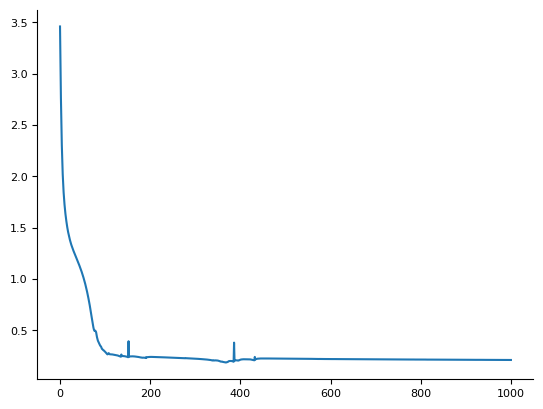

In [9]:
plt.plot(mod_train)

In [22]:
model.load_state_dict(torch.load("/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2.pt"))

<All keys matched successfully>

Model trained; now visualize the tuning. 

/home/timmy/projects/mental-rotations/src/mgplvm/mgplvm/models/svgp.py:269: UserWarning: torch.triangular_solve is deprecated in favor of torch.linalg.solve_triangularand will be removed in a future PyTorch release.
torch.linalg.solve_triangular has its arguments reversed and does not return a copy of one of the inputs.
X = torch.triangular_solve(B, A).solution
should be replaced with
X = torch.linalg.solve_triangular(A, B). (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1718580525958/work/aten/src/ATen/native/BatchLinearAlgebra.cpp:2184.)
  alpha = torch.triangular_solve(kzx, l, upper=False)[0]


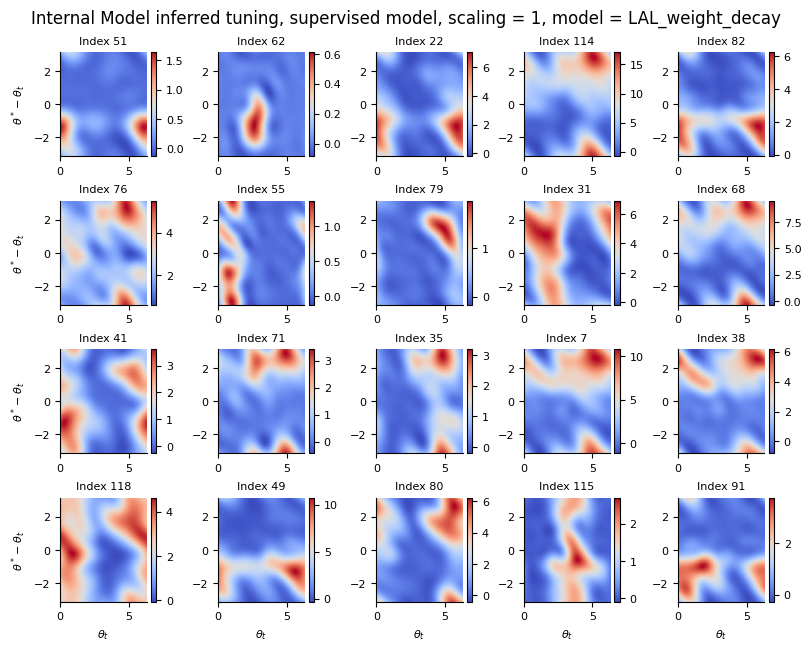

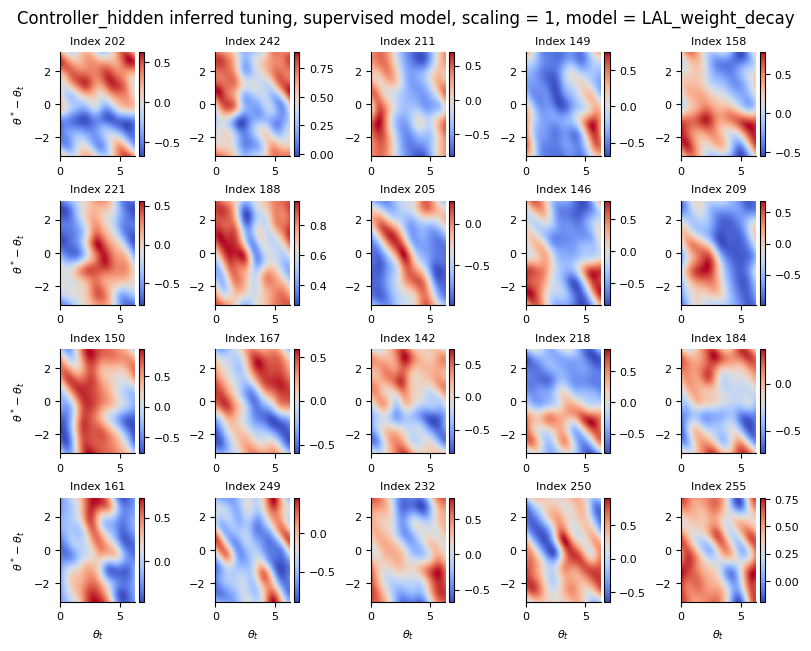

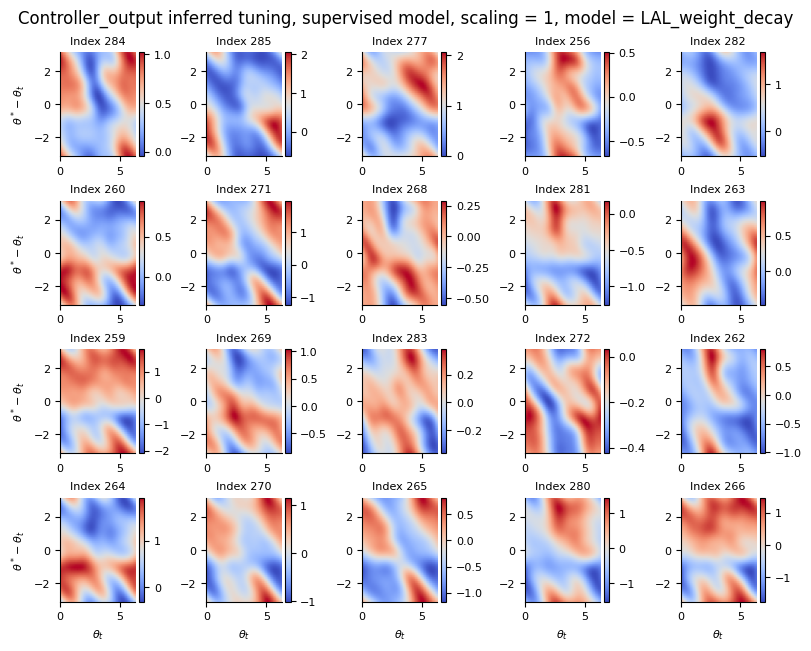

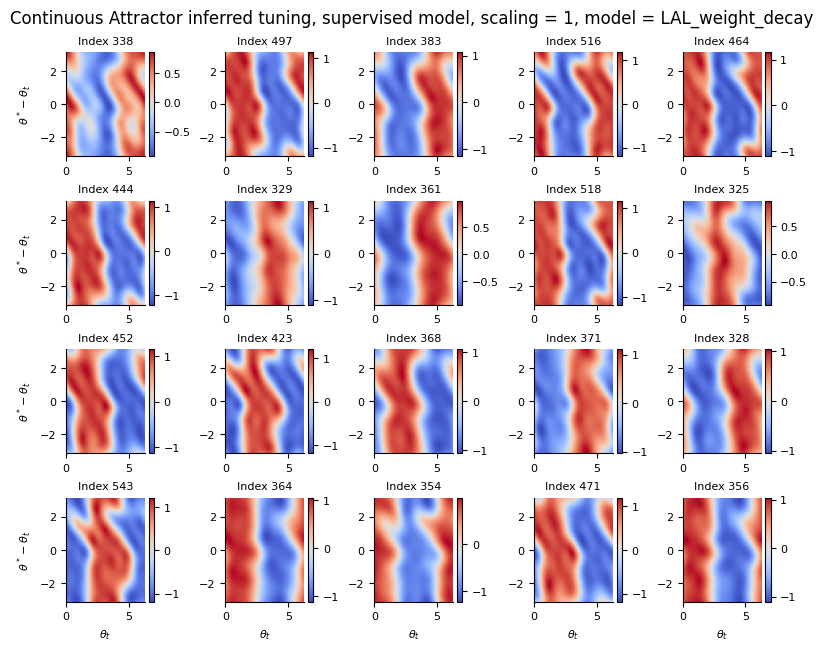

In [8]:
# Create a meshgrid for the 2D tuning curves
theta1 = np.linspace(0, 2 * np.pi, 50)
theta2 = np.linspace(-np.pi * scaling, np.pi * scaling, 50)
theta1_mesh, theta2_mesh = np.meshgrid(theta1, theta2)

# Combine the meshgrid into a query tensor
query = torch.tensor(
    np.stack([theta1_mesh.ravel(), theta2_mesh.ravel()], axis=-1),
    dtype=torch.get_default_dtype(),
    device=device,
)[None, ...].unsqueeze(-1)

# Predict mean and variance
model = model.to("cpu")
fmean, fvar = model.obs.predict(query.to("cpu"), full_cov=False)
fstd = fvar.sqrt()

# Reshape the results to match the meshgrid
fmean = fmean[0].cpu().detach().numpy().reshape(50, 50, -1)
fstd = fstd[0].cpu().detach().numpy().reshape(50, 50, -1)

subsets = {}
# Iterate over each partition and plot separately
for partition_name, (start, end) in partitions.items():
    # Find the indices in the original dataset
    indices = [i for i in range(fmean.shape[-1]) if subsampling_index_2[i] >= start and subsampling_index_2[i] <= end]
    
    # Subset the fmean for the current partition
    fmean_subset = fmean[:, :, indices]
    num_neurons = fmean_subset.shape[-1]
    subsets[partition_name] = fmean_subset
    
    # Determine grid size for plotting
    cols = 5
    # rows = (num_neurons + cols - 1) // cols  # Calculate rows dynamically based on number of neurons
    rows = 4
    
    # Create a grid of heatmaps
    fig, axes = plt.subplots(rows, cols, figsize=(8, rows * 8/5), constrained_layout=True)
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        if i >= len(axes):
            break
        ax = axes[i]
        heatmap = ax.imshow(
            fmean_subset[:, :, i],
            extent=(0, 2 * np.pi, -np.pi, np.pi),
            origin="lower",
            cmap="coolwarm",
            aspect="auto",
        )
        ax.set_title(f"Index {subsampling_index_2[idx]}")
        if i % cols == 0:
            ax.set_ylabel(r"$\theta^* - \theta_t$")
        if i // cols == rows - 1:
            ax.set_xlabel(r"$\theta_t$")
        # fig.colorbar(heatmap, ax=ax, orientation="vertical")
        fig.colorbar(heatmap, ax=ax, orientation="vertical")
    
   
    # Add a title for the grid
    plt.suptitle(f"{partition_name} inferred tuning, supervised model, scaling = {scaling}{", model = " + model_name if model_name is not None else ""}", fontsize=12)
    plt.savefig(f"{FIG_PATH}/supervised_model_modular_{partition_name}_scaling{scaling}_{model_name if model_name is not None else ""}.png", dpi=300, bbox_inches='tight')
    plt.show()


In [12]:
torch.save(model.state_dict(), f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_{model_name}.pt")
torch.save({"index 1": subsampling_index_1, "index 2": subsampling_index_2}, f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_indices_{model_name}.pt")

In [7]:
model.load_state_dict(torch.load(f"/home/timmy/storage/mental_rotations/saved_datasets/svgp_lvm_model_supervised_t2_{model_name}.pt"))

<All keys matched successfully>

# Single dimension tuning analysis

To further replicate figures in Mussells Pires et al. 2024, we look at single dimensional tuning curves.


## Observation 1: joint tuning

- this corresponds to figure 3 in the paper
- 3d: observing that lots of cells are tuned to a current angle. 

In [13]:
controller_population_activity = neural_activations[:, partitions["Controller_output"][0]:partitions["Controller_output"][1]]
subsampled_controller_population_activity = neural_activations[subsampling_index_1][:, partitions["Controller_output"][0]:partitions["Controller_output"][1]].cpu().detach().numpy()

In [14]:
print(subsampled_controller_population_activity.shape)
print(positions_subsampled.shape)
current_angles = positions_subsampled[:, 0].cpu().numpy()
residual_angles = positions_subsampled[:, 1].cpu().numpy()
target_angles = (current_angles + residual_angles) % (2 * np.pi)

(8000, 32)
torch.Size([8000, 2])


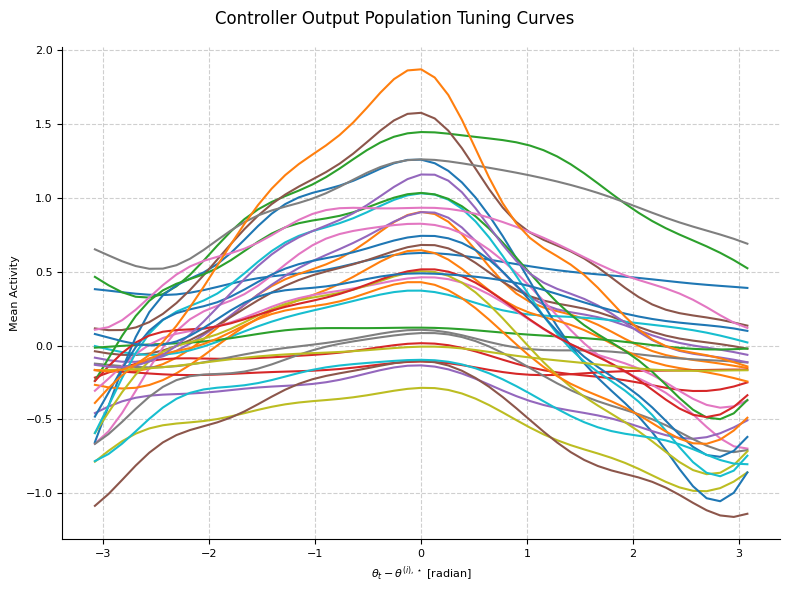

In [9]:
controller_means = subsets["Controller_output"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Output Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
state_dict = torch.load(MODEL_SAVE_PATH + "/LAL/modularized_cp_5")
model_state_dict = state_dict["model_state_dict"]

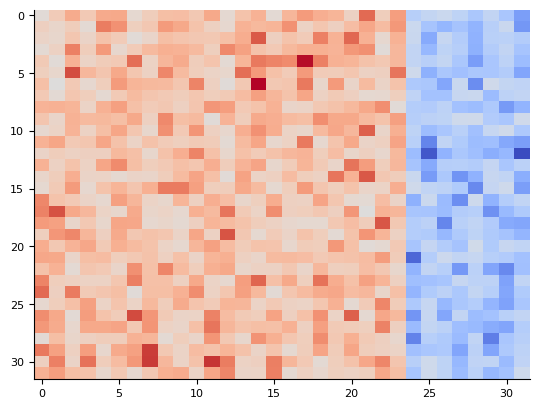

In [11]:
import torch.nn.functional as F

W_pos = F.softplus(model_state_dict["plant.W_param"]) * model_state_dict["plant.dale_signs"]
plt.imshow(W_pos.cpu().numpy(), cmap="coolwarm", aspect="auto")

In [61]:
reindex = subsampling_index_2[128:128+32] - 256
subsampled_index_controller_out = torch.zeros(32)
for i in range(32):
    subsampled_index_controller_out[i] = torch.where(reindex == i)[0][0]

subsampled_index_controller_out

tensor([ 3., 24., 31., 10.,  5., 21., 14.,  9., 15., 17., 19., 25.,  7., 11.,
        16.,  6., 13., 23., 22., 30., 29.,  2., 20., 28., 18.,  8.,  4., 12.,
         0.,  1., 27., 26.])

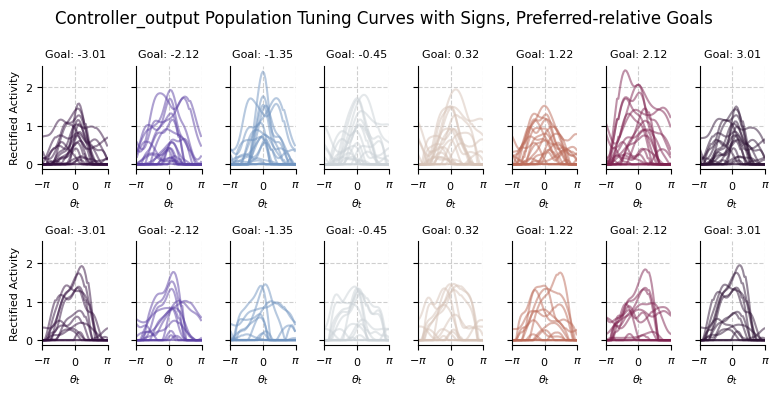

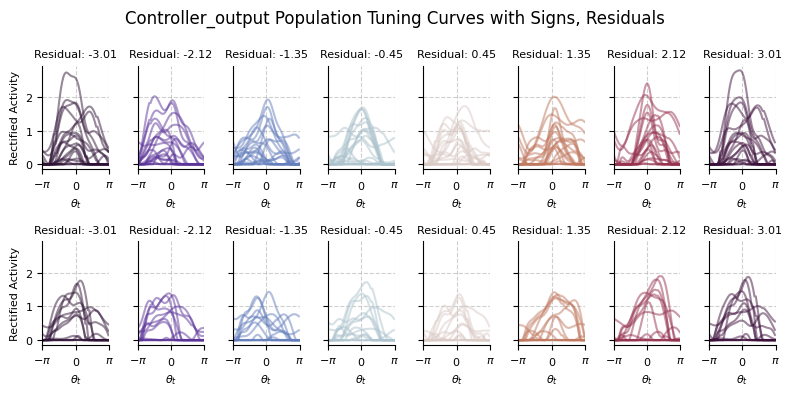

In [107]:
reindex = subsampling_index_2[128:128+32] - 256
subsampled_index_controller_out = torch.zeros(32)
for i in range(32):
    subsampled_index_controller_out[i] = torch.where(reindex == i)[0][0]

subsampled_index_controller_out
squared = False
scaled = False
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_signs = controller_signs.cpu().numpy()
controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
reindex = subsampling_index_2[128:128+32]
# utils.plot_joint_tuning("Controller_output", subsets, theta1, theta2, np.array(subsampled_index_controller_out.cpu().numpy(), dtype = np.int16), controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)
utils.plot_joint_tuning("Controller_output", subsets, theta1, theta2, reindex - 256, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

In [55]:
positions_subsampled[..., 0] = ((positions_subsampled[..., 0] + np.pi) % (2 * np.pi) - np.pi)

## what we found was that the output control cells are organized by residual rotations. 

What about the hidden cells?

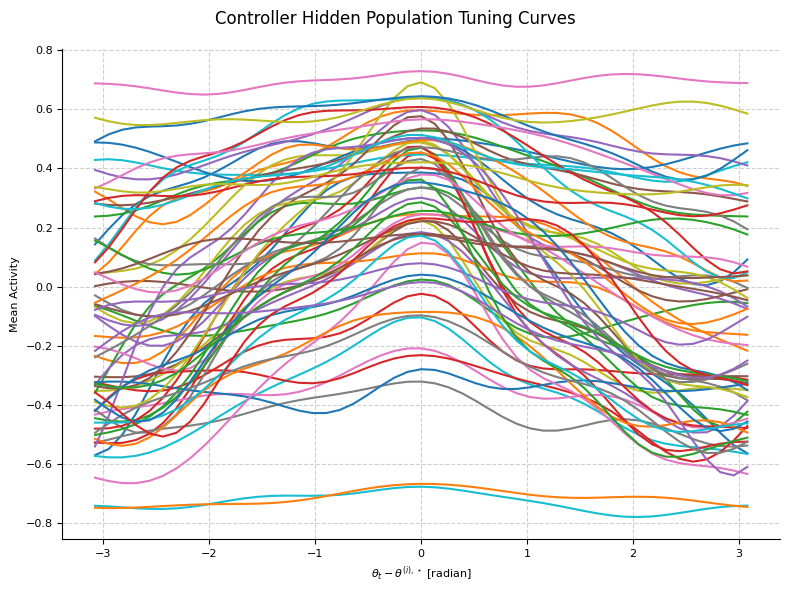

In [18]:
controller_means = subsets["Controller_hidden"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 6))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Controller Hidden Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves_hidden.png", dpi=300, bbox_inches="tight")
plt.show()

[-1. -1.  1. -1.  1.  1. -1. -1.  1.  1.  1. -1. -1.  1.  1. -1.  1.  1.
 -1.  1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.]


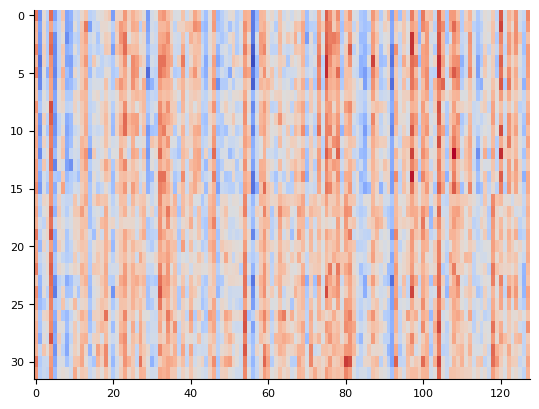

In [19]:
W_control = W_pos @ model_state_dict["out.weight"] 
plt.imshow(W_control.cpu().numpy(), cmap="coolwarm", aspect="auto")
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_signs = controller_signs.cpu().numpy()
print(controller_signs)

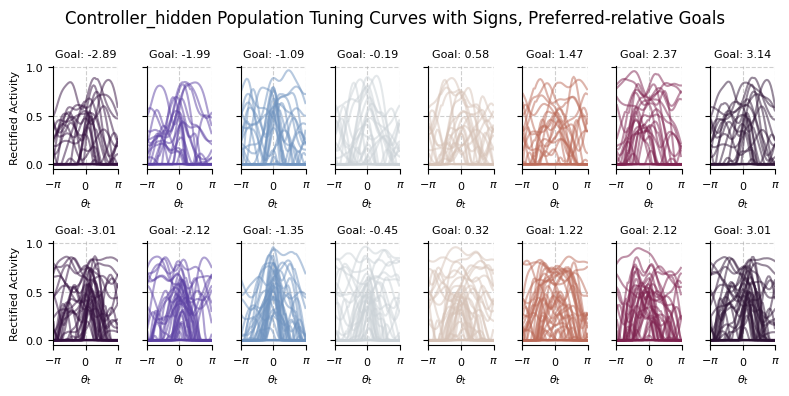

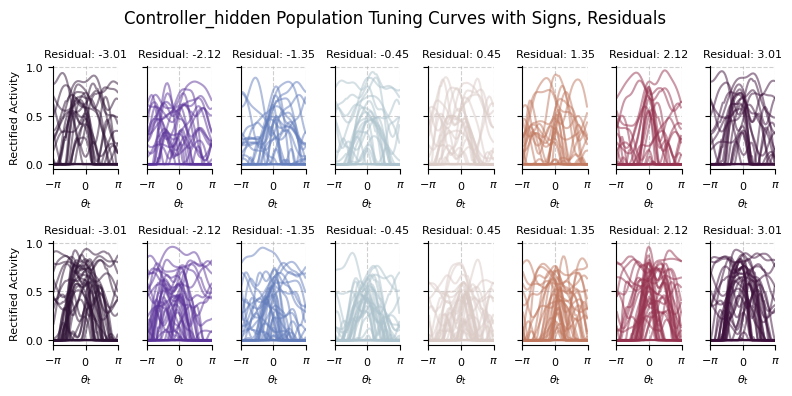

In [108]:
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()
reindex = subsampling_index_2[64:128] 
utils.plot_joint_tuning("Controller_hidden", subsets, theta1, theta2, reindex - 128, controller_signs, controller_mags,  
                        squared = False, scaled = False, save = True, show = True)

Let's check out internal models now!

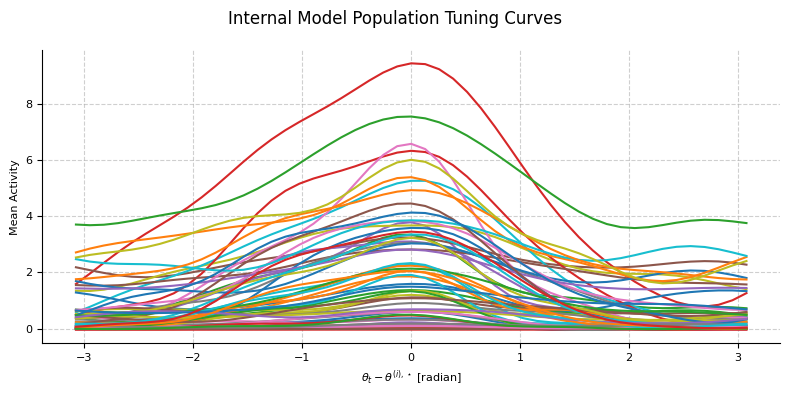

In [138]:
controller_means = subsets["Internal Model"]
theta = (theta1 + np.pi) % (2 * np.pi) - np.pi
theta = theta[:-1]

plt.figure(figsize=(8, 4))
for i in range(controller_means.shape[-1]):
    trace = controller_means[..., i].mean(axis=1)[:-1]
    shift = np.argmax(trace)  # Find the peak to align
    shifted_trace = np.roll(trace, -25-shift)
    shifted_theta = np.roll(theta, -25)  # Roll theta to match the trace
    plt.plot(shifted_theta, shifted_trace, label=f"Neuron {i+1}")

plt.xlabel(r"$\theta_t - \theta^{(i), \star}$ [radian]")
plt.ylabel("Mean Activity")
plt.suptitle("Internal Model Population Tuning Curves")
# plt.legend(loc="upper right", fontsize=8, frameon=False)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig(f"{FIG_PATH}/controller_population_tuning_curves_im.png", dpi=300, bbox_inches="tight")
plt.show()

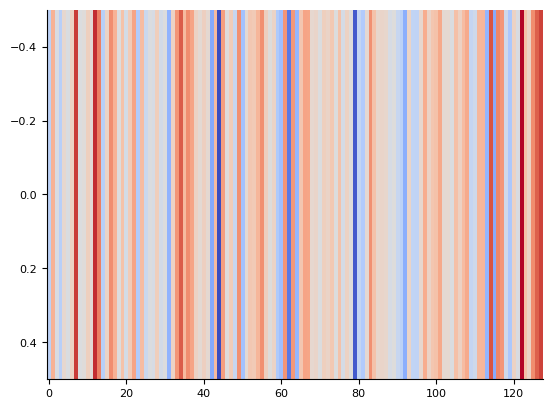

In [23]:
plt.imshow(model_state_dict["im1.W_output.weight"].cpu().detach().numpy(), cmap = "coolwarm", aspect = "auto")

In [164]:
subsets.keys()

dict_keys(['Internal Model', 'Controller_hidden', 'Controller_output', 'Continuous Attractor'])

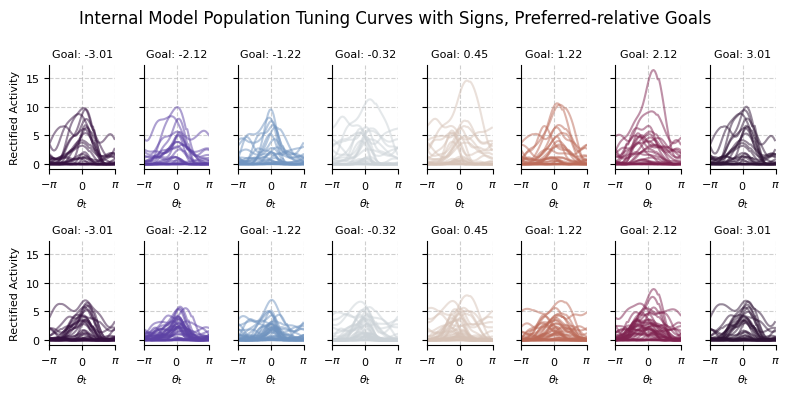

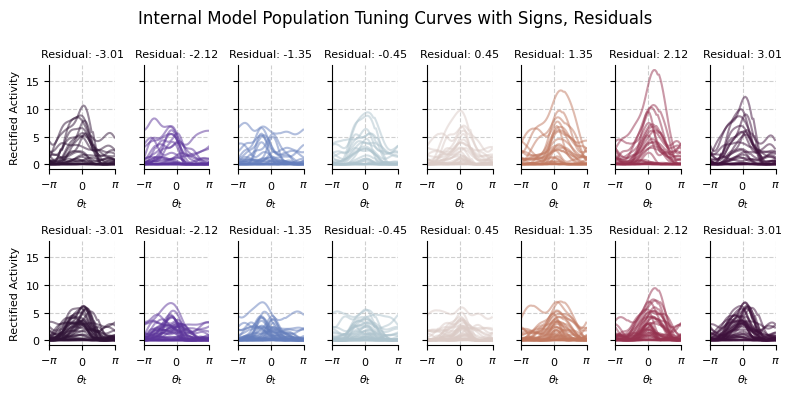

In [110]:
squared = False
scaled = False
controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
reindex = subsampling_index_2[0:64]
utils.plot_joint_tuning("Internal Model", subsets, theta1, theta2, reindex, controller_signs, controller_mags, squared = squared, scaled = scaled, save = True, show = True)

# Raw data

we use the same procedure to plot for the raw data now. Respectively for each cell type, we can check the tuning curve from binned averaged mGPLVM fits as well as raw data

## First do controller output

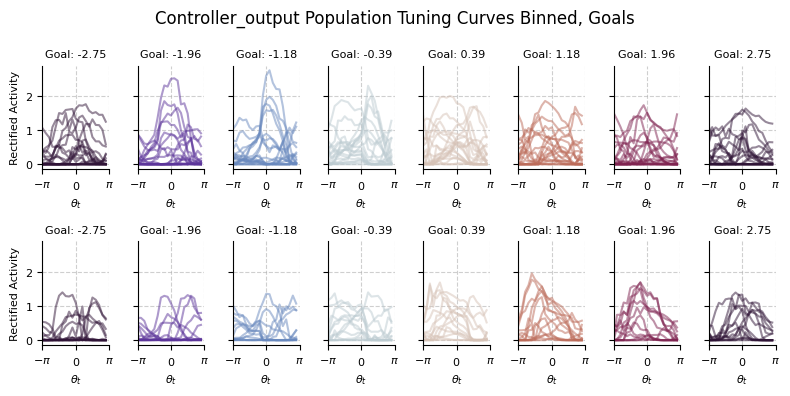

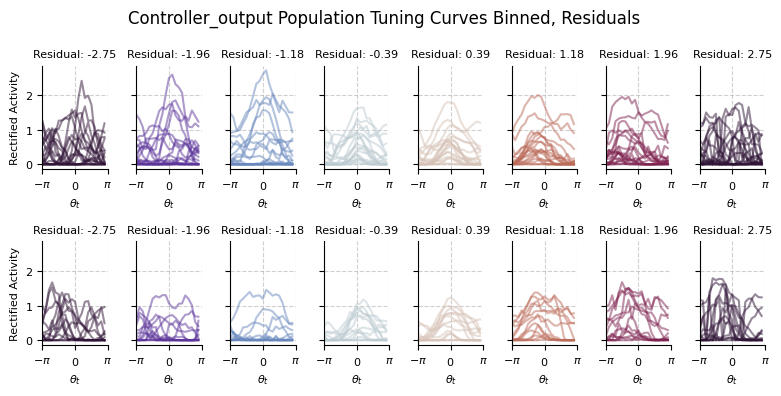

In [126]:
population = "Controller_output"
squared = False
scaled = False
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions[population][0]:partitions[population][1]]
utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = True, show = True, n_bins = 8,n_theta_bins = 20, population =population,
)

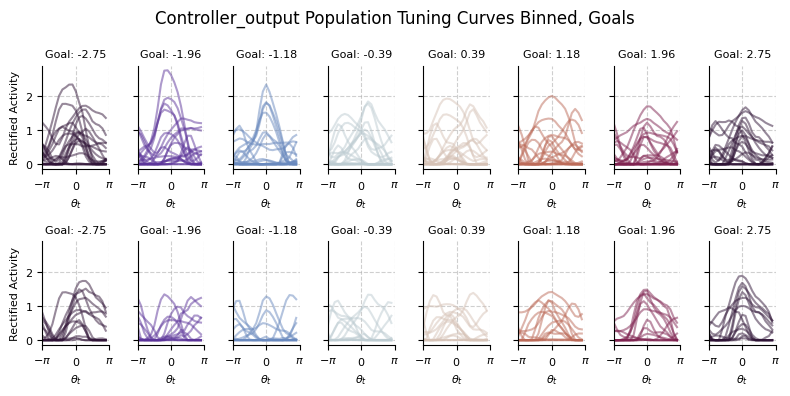

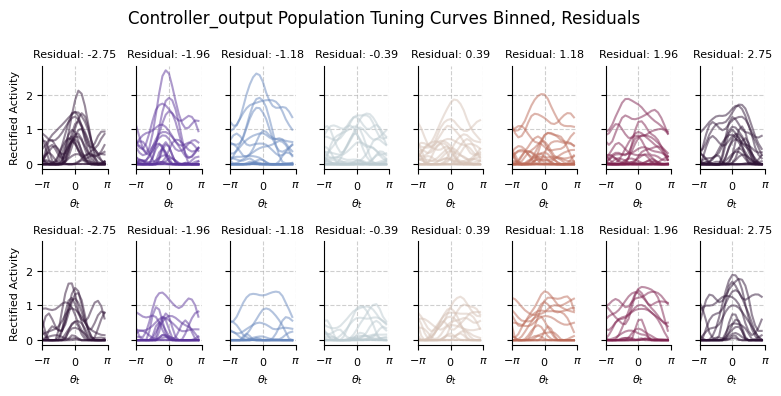

In [128]:
#check agreement with mgplvm activations
squared = False
scaled = False
controller_signs = torch.sign(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_pos[:16, :].sum(axis = 0) - W_pos[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

reindex = np.array(subsampling_index_2[128:160], dtype = np.int16) - 256
utils.plot_joint_tuning_binned(
    activations=subsets["Controller_output"].reshape(-1, subsets["Controller_output"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index=reindex,
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 20, population = "Controller_output",
)

## Then same thing for the hidden controller units

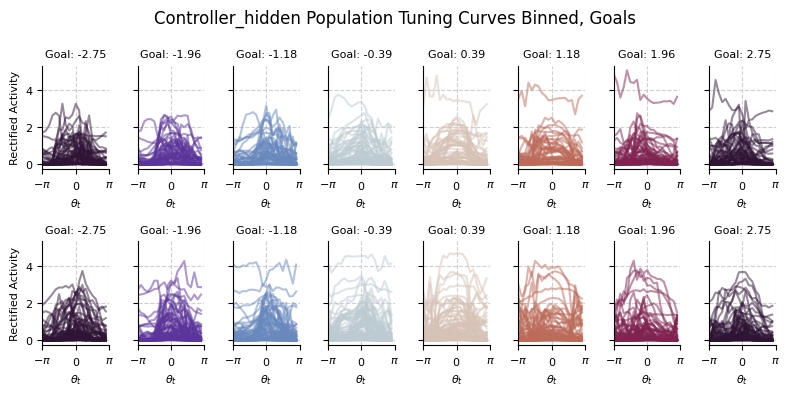

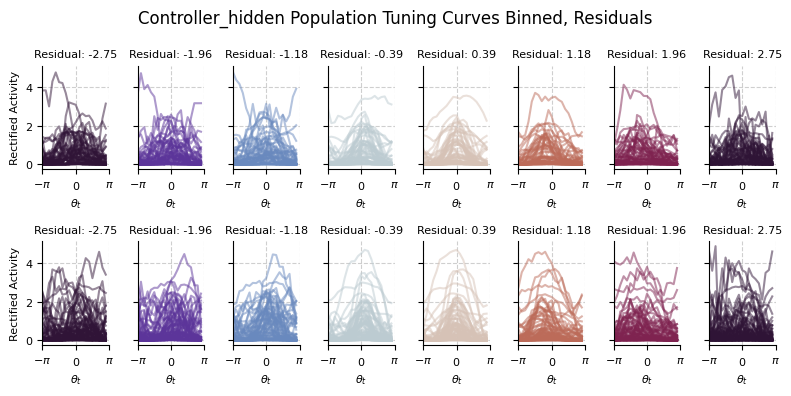

In [132]:
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions["Controller_hidden"][0]:partitions["Controller_hidden"][1]]
squared = False
scaled = True
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 20, population = "Controller_hidden",
)

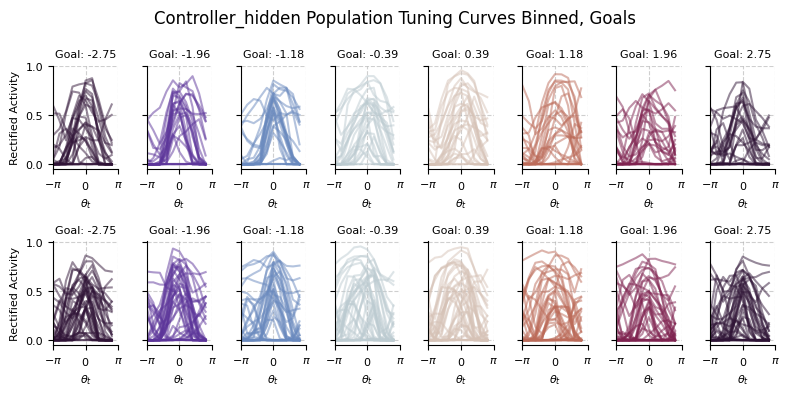

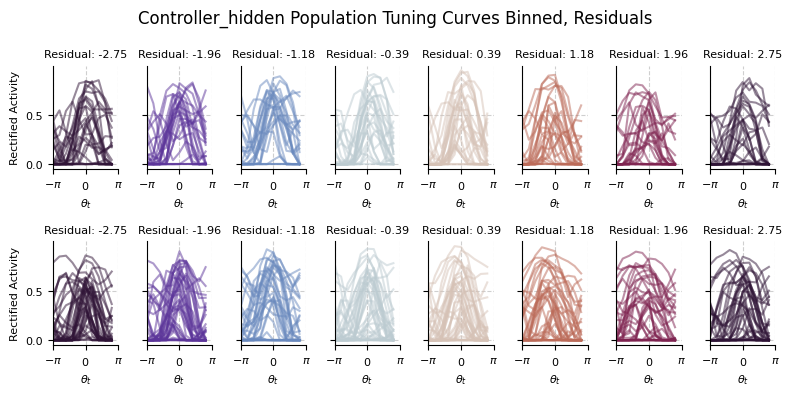

In [130]:
squared = False
scaled = False
controller_signs = torch.sign(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0))
controller_mags = torch.abs(W_control[:16, :].sum(axis = 0) - W_control[16:, :].sum(axis = 0)).cpu().numpy()
controller_signs = controller_signs.cpu().numpy()

reindex = np.array(subsampling_index_2[64:128], dtype = np.int16) - 128
utils.plot_joint_tuning_binned(
    activations=subsets["Controller_hidden"].reshape(-1, subsets["Controller_hidden"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index = reindex, 
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population = "Controller_hidden",
)

Finally internal model

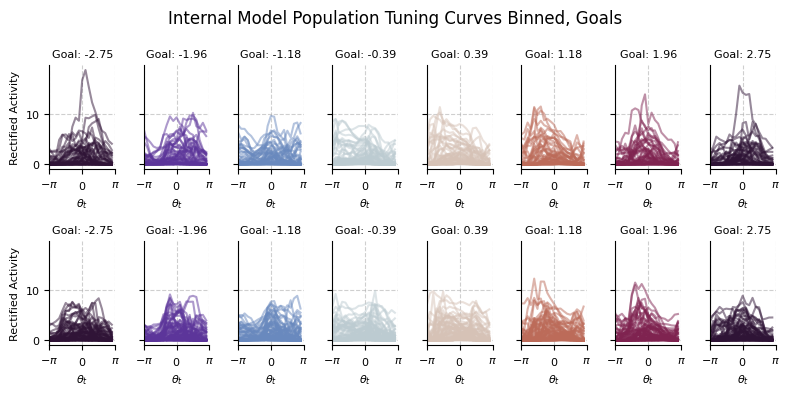

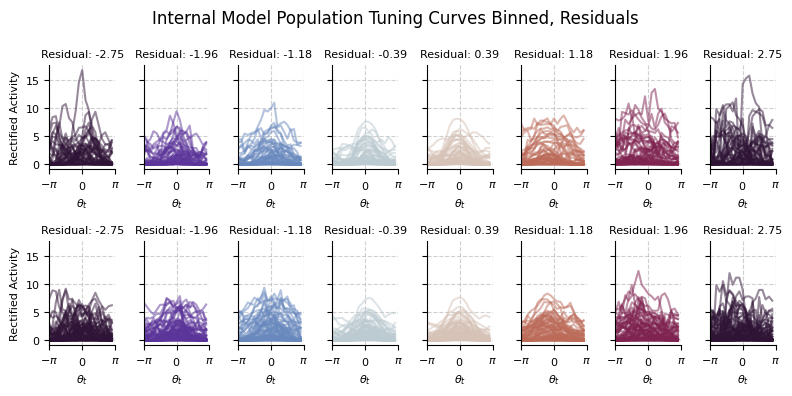

In [136]:
subsampled_controller_hidden = neural_activations[subsampling_index_1][:, partitions["Internal Model"][0]:partitions["Internal Model"][1]]
squared = False
scaled = False

controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
utils.plot_joint_tuning_binned(
    activations=subsampled_controller_hidden,
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    thetas = positions_subsampled, 
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 20, population = "Internal Model",
)

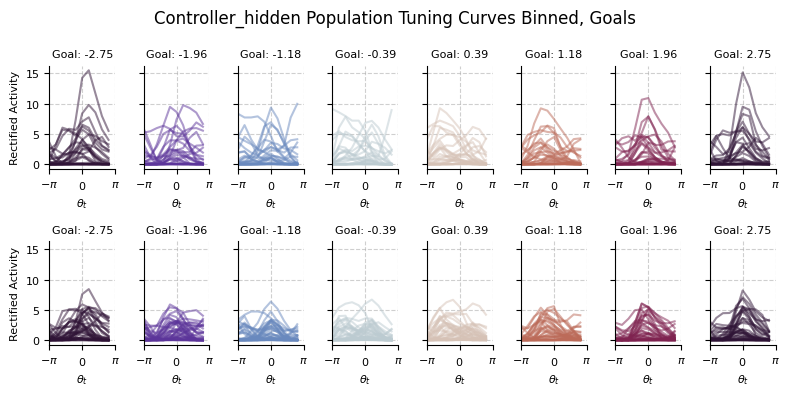

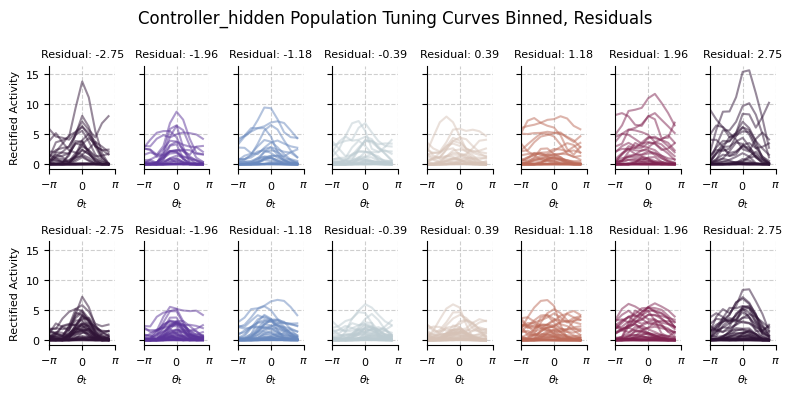

In [137]:
squared = False
scaled = False

controller_signs = torch.sign(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()
controller_mags = torch.abs(model_state_dict["im1.W_output.weight"].reshape(-1)).cpu().numpy()

reindex = np.array(subsampling_index_2[:64], dtype = np.int16) 
utils.plot_joint_tuning_binned(
    activations=subsets["Internal Model"].reshape(-1, subsets["Internal Model"].shape[-1]),
    controller_signs=controller_signs,
    controller_mags=controller_mags,
    subsample_index = reindex, 
    thetas = np.concatenate((theta1_mesh.reshape(-1, 1), theta2_mesh.reshape(-1, 1)), axis = -1),
    squared=squared, scaled=scaled, 
    save = False, show = True, n_bins = 8,n_theta_bins = 10, population = "Controller_hidden",
)